# Permeator Probe plotting and post-processing for FESTIM simulation results. 

## Steady State Analysis 

Compare inlet, outlet, and probe surface fluxes. 

In [3]:
import numpy as np


permeation_flux = np.genfromtxt(
    "festim_results_probe_in_benchmark/permeation_flux.csv", delimiter=",", names=True
)
outlet_advective_flux = np.genfromtxt(
    "festim_results_probe_in_benchmark/outlet_advective_flux.csv", delimiter=",", names=True
)
inlet_advective_flux = np.genfromtxt(
    "festim_results_probe_in_benchmark/inlet_advective_flux.csv", delimiter=",", names=True
)

probe_flux = permeation_flux["H_flux_surface_7"]
outlet_flux = outlet_advective_flux["H_advection_flux_surface_6"]
inlet_flux = inlet_advective_flux["H_advection_flux_surface_4"]

# assert probe_flux + outlet_flux <= inlet_flux # mass conservation 

percent_lost_to_permeation = probe_flux/inlet_flux * 100
percent_at_outlet = outlet_flux/inlet_flux * 100

print(f"Permeation flux into probe is {percent_lost_to_permeation}% of inlet flux.")
print(f"Advective flux at outlet is {percent_at_outlet}% of inlet flux.")



Permeation flux into probe is 8.450946652651198e-16% of inlet flux.
Advective flux at outlet is -101.06438605865769% of inlet flux.


## Transient Analysis

Plot to compare advective flux at breeder outlet to permeation flux at probe surface. 

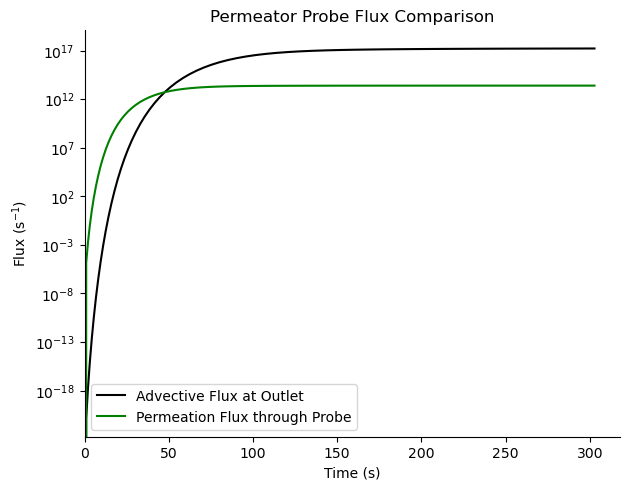

In [8]:
import matplotlib.pyplot as plt
import numpy as np


outlet_surface_flux = np.genfromtxt(
    "festim_results/outlet_surface_flux.csv", delimiter=",", names=True
)

advective_flux_outlet_t = outlet_surface_flux["ts"] # time
advective_flux_outlet = outlet_surface_flux["H_advection_flux_surface_2"] # field

# append t=0 value=0 at start of data
advective_flux_outlet_t = np.insert(advective_flux_outlet_t, 0, 0)
advective_flux_outlet = np.insert(advective_flux_outlet, 0, 0)

probe_surface_flux = np.genfromtxt(
    "festim_results/probe_surface_flux.csv", delimiter=",", names=True
)

permeation_flux_probe_t = probe_surface_flux["ts"] # time
permeation_flux_probe = probe_surface_flux["H_flux_surface_4"] # field

# append t=0 value=0 at start of data
permeation_flux_probe_t = np.insert(permeation_flux_probe_t, 0, 0)
permeation_flux_probe = np.insert(permeation_flux_probe, 0, 0)

plt.figure()
plt.plot(advective_flux_outlet_t, advective_flux_outlet, color="black", label="Advective Flux at Outlet")
plt.plot(permeation_flux_probe_t, permeation_flux_probe, color="green", label="Permeation Flux through Probe")
# plt.fill_between(permeation_flux_probe_t, permeation_flux_probe, color="green", alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel(r"Flux (s$^{-1}$)")
plt.xlim(left=0)
plt.yscale('log')
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend()
plt.tight_layout()
plt.title("Permeator Probe Flux Comparison")

plt.show()

Plot for permeation flux at probe surface.

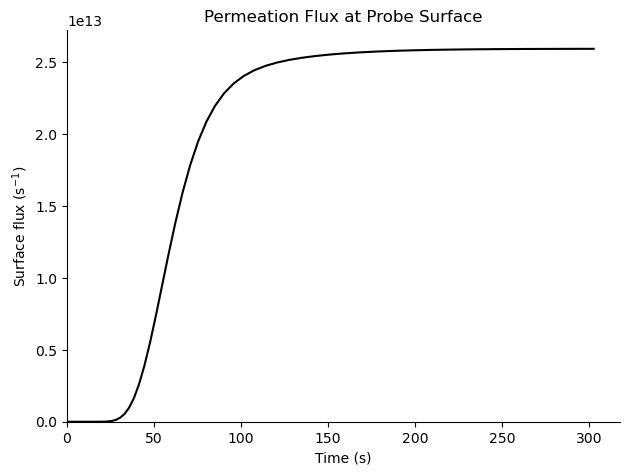

In [3]:
import matplotlib.pyplot as plt
import numpy as np


probe_surface_flux = np.genfromtxt(
    "festim_results/probe_surface_flux.csv", delimiter=",", names=True
)

surface_flux_t = probe_surface_flux["ts"] # time
surface_flux = probe_surface_flux["H_flux_surface_4"] # field

# append t=0 value=0 at start of data
surface_flux_t = np.insert(surface_flux_t, 0, 0)
surface_flux = np.insert(surface_flux, 0, 0)

plt.figure()
plt.plot(surface_flux_t, surface_flux, color="black")
plt.xlabel("Time (s)")
plt.ylabel(r"Surface flux (s$^{-1}$)")
plt.xlim(left=0)
plt.ylim(bottom=0)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.title("Permeation Flux at Probe Surface")

plt.show()